# Layout

1. Imports
2. Load DataStructure
3. Setup Parameters
4. Single Trial Trajectory
    1. Define Plotting Function
    2. Slice data (if necessary)
    3. Return Plot

5. Multi-Trial Trajectory
    1. Define Plotting Function
    2. Slice data (if necessary)
    3. Return Plot


6. Path Complexity
    1. Define Plotting Function
    2. Slice data (if necessary)
    3. Return Plot

In [1]:
##### Imports #########################################################
from pathlib import Path
import matplotlib.pyplot as plt
import movement.plots
import movement.kinematics
import movement.utils.vector
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Markdown, display



from data_conduit.datastructures import slice_stream, slice_stream_for_trial
from movement_figures.data_template.loading import build_datastructure

from movement_figures.misc import visual_streams_check, configure_simplified_trial_df
from movement_figures.timeseries_template.annotations import annotate_qc_timeseries
from movement_figures.video import read_session_video_frame



from data_conduit.refactor_qc import (                                          # Imports for trial filtering based on experiment protocol 
    TRAINING_FIRST_MID_LAST_DETAIL,
    training_spec,
    training_session_names,
    filter_trials,
)


from data_conduit.integrations.DLC.pose import pose_to_movement                 # Import for combining DLC pose & confidence streams into single object, matches `movement`'s conventions


### Notebook Settings ######################################################

pd.set_option("display.max_columns", None)                              # Changes default pandas display settings to show all columns in a dataframe.


In [2]:
##### Setup Parameters ################################################


# === 1| Select Mice, Days and Recording Folders Before Reading Files =============

ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")

LEVEL_SELECTORS = {
    'l0_selector': 'MR_M01569515', 
    'l1_selector': 'Day21'
    }                                                                               # Example choices belong here: l0_selector and l1_selector.

# INCLUDE_SESSIONS = ('2026-06-21T093349Z',)                                          # Optional list of recording folder names; None keeps selected folders.
# STREAMS = ('trials', 'events', 'video', 'dlc')                                      # These figures require events/trials and aligned pose; other sources remain available.


#=== 2| Set the trial filtering parameters for the experiment protocol ============
spec = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)                                  # Flattens `{training_detail}` table into per-session spec. 

# included_sessions = training_session_names(spec)                                      # Returns a list of session folder names that match the spec.
#   Not used here, as sessions have been filtered in another way. If other sessions 
#   not in the above spec are used, then applying the `filter_trials` function with 
#   the above spec could result in incorrect filtering. 



In [3]:
##### Load DataStructure ###############################################################


#=== Load data ========================================================================
fig_ds = build_datastructure(
    root = ROOT,                                                                        # Directory above the named hierarchy levels.
    level_names = ("mouseID", "day"),                                                   # Lab layout: root / mouseID / day / session.
    streams = ("trials", "session_settings", "video", "dlc"),
    include = None,                                                                     # Keep these session folder names; None keeps all.
    exclude = None,                                                                     # Alternatively omit these session folder names.
    raw_events = True,                                                                  # Convenience alias for adding "events" to the requested sources.
    device_yaml = "./device.yml",                                                       # Lab Nosepoke board register definitions.
    soundcard_yaml = "./soundcard.yml",                                                 # Lab SoundCard register definitions.
    nosepoke_count = 18,                                                                # Port count used by the existing Q_C parser.
    trial_start_buffer = 0.0,                                                           # Preserve the existing lab parser setting.
    trial_spec = None,                                                                  # Optional experiment rules; None keeps the existing Q_C specification. 
    #    Not used here, as sessions are already selected. 
    #    If session is not one in the spec, then subsequent use of 
    #   `filter_trials` to apply correct experiment protocol rules could be incorrect.

    dlc_file_format = "auto",                                                           # Existing reader prefers CSV, otherwise HDF5.
    **LEVEL_SELECTORS,
)


#=== Select and load the streams of interest from datastructure. ======================
fig_ds.select()
streams = fig_ds.load()



#=== Create convenient compact trial dataframe without some unnecessary columns. ======
#       More useful for visual inspection and analysis. 
#       Check the misc.py file for the default columns to keep and drop. 

streams['compact_trials'] = configure_simplified_trial_df(              
    trial_df = streams['trials'],
    modify_in_place = False,                                            # Whether to modify the trial dataframe in place or return a new dataframe. 
)


#=== Apply Trial Filtering Protocol to construct new stream objects ===================
streams['filtered_trials'] = filter_trials(
    trials = streams['trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

streams['filtered_compact_trials'] = filter_trials(
    trials = streams['compact_trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

#=== Merge Pose & Confidence Streams ==================================================
streams['dlc:movement'] = pose_to_movement(
    slice_stream(streams["dlc:position"], #selectors={"session": session_id}
    ),
    slice_stream(streams["dlc:confidence"], #selectors={"session": session_id}
    ),
)
display(streams['dlc:movement'])


#=== Visual streams check =============================================================
visual_streams_check(
    loaded_ds_object = streams,
    show_stream_shapes = True,
    show_stream_dtypes = True,
    display_streams = False
)

     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80
     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80


<xarray.Dataset> Size: 8MB
Dimensions:     (individual: 1, keypoint: 5, space: 2, time: 36354)
Coordinates:
  * individual  (individual) object 8B 'individual_0'
  * keypoint    (keypoint) <U8 160B 'nose' 'lear' 'rear' 'body' 'tailbase'
  * space       (space) <U1 8B 'x' 'y'
  * time        (time) float64 291kB 5.633e+03 5.633e+03 ... 7.451e+03 7.451e+03
    session     (time) <U18 3MB '2026-06-21T093349Z' ... '2026-06-21T093349Z'
    mouseID     (time) object 291kB 'MR_M01569515' ... 'MR_M01569515'
    day         (time) object 291kB 'Day21' 'Day21' 'Day21' ... 'Day21' 'Day21'
Data variables:
    position    (time, space, keypoint, individual) float64 3MB 1.209e+03 ......
    confidence  (time, keypoint, individual) float64 1MB 0.9686 1.0 ... 0.9815
Attributes:
    source_software:  DeepLabCut
    time_unit:        seconds
    spatial_unit:     pixels

=========================
### Summary of Loaded Streams
=========================

,Stream Name,Shape,Type
0,session_settings:metadata,"(1, 23)",DataFrame
1,session_settings:trials,"(303, 132)",DataFrame
2,video,"(36354, 5)",DataFrame
3,dlc:position,"(36354, 5, 2)",DataArray
4,dlc:confidence,"(36354, 5)",DataArray
5,events,"(1487, 5)",DataFrame
6,trials,"(106, 28)",DataFrame
7,compact_trials,"(106, 19)",DataFrame
8,filtered_trials,"(80, 30)",DataFrame
9,filtered_compact_trials,"(80, 21)",DataFrame


In [4]:
from data_conduit.datastructures import slice_stream_per_trial, slice_stream


selected_trials = slice_stream(
    streams['filtered_trials'][:6]
    #streams["filtered_trials"], selectors={"trial_index": slice(1, 8)},
)


# Body positions for the recording.
point = streams['dlc:movement'].sel(keypoint="body", drop=True)

# Get positions for each complete selected trial.
selected = slice_stream_per_trial(
    stream=point,
    trials=selected_trials,
    segment="trial",
    time_coord="time",
)

# Get outbound positions using the trial table's outbound boundaries.
outbound = slice_stream_per_trial(
    stream=point,
    trials=selected_trials,
    segment="outbound",
    time_coord="time",
)

# Get inbound positions using the trial table's inbound boundaries.
inbound = slice_stream_per_trial(
    stream=point,
    trials=selected_trials,
    segment="inbound",
    time_coord="time",
)

# Each call above returns a list containing one position slice per trial.
# Join those slices along time to provide the positions for each heatmap.
occupancy_points = {
    "Selected trials": xr.concat(selected, dim="time"),
    "Outbound": xr.concat(outbound, dim="time"),
    "Inbound": xr.concat(inbound, dim="time"),
}



display(selected_trials)

# Select positions for every chosen trial, keeping all keypoints.
angle_positions = slice_stream_per_trial(
    stream=streams['dlc:movement'],
    trials=selected_trials,
    segment="trial",
    time_coord="time",
)

# Join the selected trial slices along time.
angle_positions = xr.concat(angle_positions, dim="time")



##### Video Background and Static ROI #####

# Read the video for the single recording represented by the selected trials.
session_id = selected_trials["session"].unique().item()
background_frame, video_path = read_session_video_frame(fig_ds.sessions[session_id].path)

,trial_index,start_time,end_time,start_inclusive,end_inclusive,first_event_index,last_event_index,tz_triggered_time,tz_available_time,ChosenPort,CorrectPort,outcome,LED,angle_offset,target_zone_size,TTT,TTP,outbound_start_time,outbound_end_time,outbound_start_inclusive,outbound_end_inclusive,inbound_start_time,inbound_end_time,inbound_start_inclusive,inbound_end_inclusive,session,mouseID,day,training_day,day_trial_index
0,24,5922.650944,5930.218816,False,True,332,345,5928.000992,5925.144000,0,0,Success,OFF,0.0,300.0,5.350048,2.217824,5922.650944,5928.000992,False,True,5928.000992,5930.218816,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,1
1,25,5930.218816,5937.076640,False,True,346,359,5935.200000,5932.724000,0,0,Success,OFF,0.0,300.0,4.981184,1.876640,5930.218816,5935.200000,False,True,5935.200000,5937.076640,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,2
2,26,5937.076640,5947.709248,False,True,360,373,5944.049984,5939.589984,0,0,Success,OFF,0.0,300.0,6.973344,3.659264,5937.076640,5944.049984,False,True,5944.049984,5947.709248,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,3
3,27,5947.709248,5956.329760,False,True,374,387,5953.200000,5950.220992,0,0,Success,OFF,0.0,300.0,5.490752,3.129760,5947.709248,5953.200000,False,True,5953.200000,5956.329760,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,4
4,28,5956.329760,5963.959072,False,True,388,401,5962.250976,5958.838976,0,0,Success,OFF,0.0,300.0,5.921216,1.708096,5956.329760,5962.250976,False,True,5962.250976,5963.959072,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,5
5,29,5963.959072,5980.614496,False,True,402,415,5975.602976,5970.956992,-1,0,Miss,OFF,NaN,150.0,11.643904,5.011520,5963.959072,5975.602976,False,True,5975.602976,5980.614496,True,True,2026-06-21T093349Z,MR_M01569515,Day21,3,6


In [5]:
# display(background_frame)

In [6]:
# fig, ax = plt.subplots()
# ax.imshow(background_frame[:-2], origin="upper")
# ax.set_aspect("equal")
# plt.show()

# fig, ax = plt.subplots()
# ax.imshow(background_frame[:-1], origin="upper")
# ax.set_aspect("equal")
# plt.show()


---------------------------
# Figure Functions
----------------------------

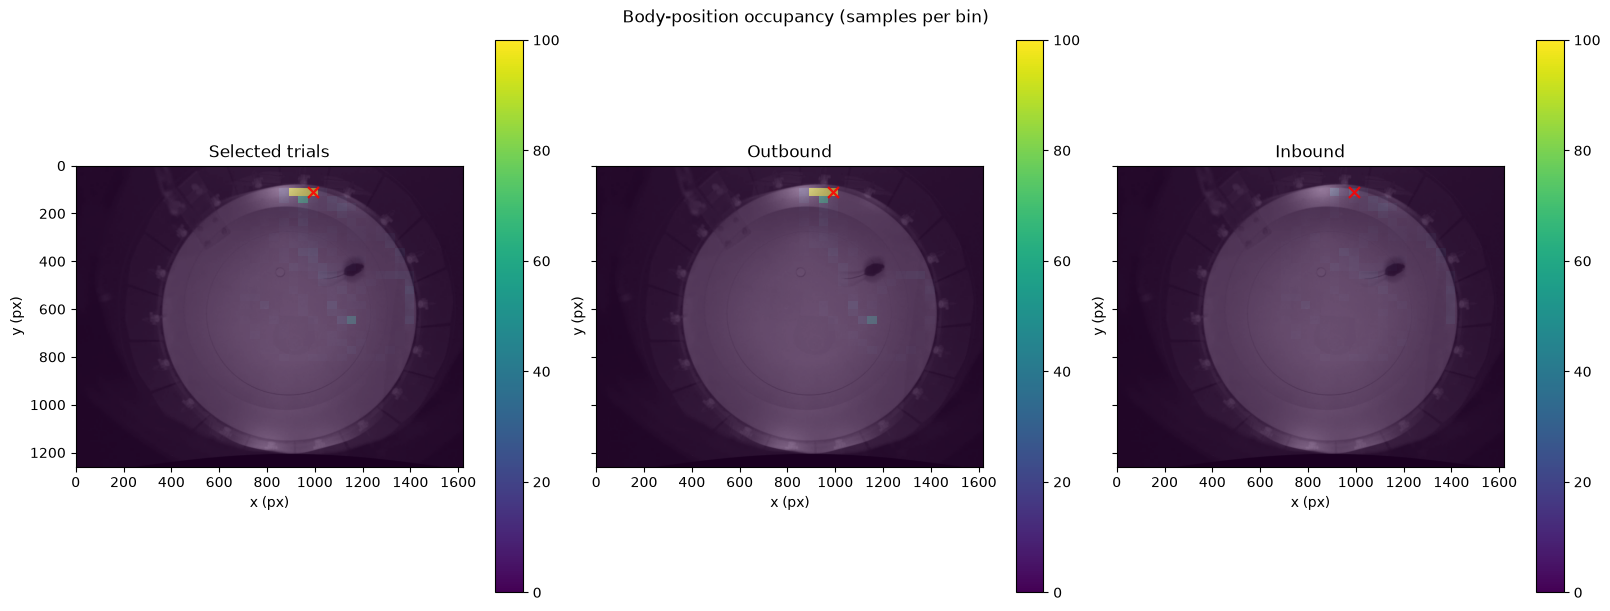

In [7]:
##### Spatial Occupancy Plot #####

def plot_spatial_occupancy(
    points, 
    background_frame, 
  #  fixed_roi_px, 
    *, 
    # roi_label="North / top of video",
    bins=40, 
    vmax=100.0,
    cmap = "viridis",
    cmap_norm = "linear", 
    alpha=0.40,
    show_roi_marker = True,
):
    """Plot body-position occupancy over the first video frame using movement.

    Each panel counts the selected position samples falling inside each spatial
    bin. This is a sample-count map: it is not normalised to seconds or to a
    probability. Trial selection and any confidence filtering happen earlier.

    Parameters
    ----------
    points : dict[str, xarray.Dataset]
        Panel labels mapped to selected pose datasets, as in occupancy_points.
        Each dataset contains position in video pixels for the body keypoint.
        The arrays and background must belong to the same recording. movement
        omits positions with missing coordinates; binning covers the video area.
    background_frame : numpy.ndarray
        First RGB frame of the matching video, with shape (height, width, 3).
        Its dimensions set the common image extent and histogram boundaries.
    fixed_roi_px : array-like
        ROI marker (x, y) in video pixels, shared with the static-bearing figure.
        The marker identifies the target; it does not change the sample counts.
    roi_label : str
        Target name displayed in each panel's legend.
    bins : int
        Number of equal-width bins along each image axis. For example, 30
        produces a 30 by 30 grid covering the full video frame.
    vmax : float
        Upper colour limit in samples per bin, used for every panel. Larger
        counts use the top colour but retain their full values in occupancy.
    alpha : float
        Heatmap opacity from 0 (transparent) to 1 (opaque). movement supplies
        each panel's colour bar and normal rendering, including zero-count bins.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Occupancy figure with one colour bar per panel, ready to display or save.
    axes : numpy.ndarray
        One-dimensional array of panel axes, in the order supplied by points.
    occupancy : dict
        movement's histogram result for each panel label: h holds raw counts
        indexed by x bin then y bin; xedges and yedges hold the bin boundaries
        in pixels. Each edge array has one more value than the number of bins.
    """
    # --- Match the panels and histogram bins to the video ---
    height, width = background_frame.shape[:2]

    
    extent = (-0.5, width - 0.5, height - 0.5, -0.5)                # The image extent in pixels, with y increasing downwards. The -0.5 offset centers the first and last bins on the first and last pixels, respectively.
    bin_range = ((-0.5, width - 0.5), (-0.5, height - 0.5))         # The bin boundaries in pixels, with y increasing downwards. The -0.5 offset centers the first and last bins on the first and last pixels, respectively.
    fig, grid = plt.subplots(
        1, len(points), figsize=(16, 6), squeeze=False,
        sharex=True, sharey=True, layout="constrained",
    )
    axes = grid[0]
    occupancy = {}

    # --- Plot occupancy and the ROI marker ---
    for ax, (label, point) in zip(axes, points.items()):
        ax.imshow(background_frame, origin="upper", extent=extent)
        _, _, occupancy[label] = movement.plots.plot_occupancy(
            da=point["position"],                                   # Coordinates from the selected pose dataset.
            ax=ax, 
            bins=bins, 
            range=bin_range,
            cmap=cmap, 
            vmin=0, 
            vmax=vmax, 
            alpha=alpha,
            norm = cmap_norm
        )
        # ax.scatter(
        #     *fixed_roi_px, marker="*", s=110, color="gold",
        #     edgecolor="black", label=roi_label,
        # )
        # ax.legend()
        ax.set(
            title=label, xlabel="x (px)", ylabel="y (px)", aspect="equal",
            xlim=extent[:2], ylim=extent[2:],  # Video y increases downwards.
        )

        panel = "Selected trials"  # Alternatively: "Outbound" or "Inbound"
        hist = occupancy[panel]
        counts = np.asarray(hist["h"])

        if not np.isfinite(counts).any() or np.nanmax(counts) <= 0:
            raise ValueError("This occupancy panel contains no observations.")

        # movement returns h indexed by x-bin, then y-bin.
        ix, iy = np.unravel_index(np.nanargmax(counts), counts.shape)

        fixed_roi_px = np.array([
            (hist["xedges"][ix] + hist["xedges"][ix + 1]) / 2,
            (hist["yedges"][iy] + hist["yedges"][iy + 1]) / 2,
        ])

        if show_roi_marker:
            for ax in axes:
                ax.scatter(
                    *fixed_roi_px,
                    marker="x",
                    s=60,
                    color="red",
                    # edgecolor="black",
                    # linewidth=0.8,
                    zorder=10,
                    label=f"Most occupied: {panel}",
                    alpha= 0.5
                )
    # ax.legend()

        

    fig.suptitle("Body-position occupancy (samples per bin)")
    return fig, axes, occupancy, fixed_roi_px


##### Return the Occupancy Figure #####

occupancy_figure, occupancy_axes, occupancy, fixed_roi_px = plot_spatial_occupancy(
    points=occupancy_points,
    background_frame=background_frame,
    show_roi_marker=True,
)

occupancy_figure.savefig("occupancy_figure_heatmap_all.png")

plt.close(occupancy_figure)  # The last line displays the returned figure once.
occupancy_figure


In [8]:
# ##### Return the Occupancy Figure #####

# occupancy_figure, occupancy_axes, occupancy = plot_spatial_occupancy(
#     points=occupancy_points,
#     background_frame=background_frame,
# )
# plt.close(occupancy_figure)  # The last line displays the returned figure once.
# occupancy_figure


In [9]:
##### Video Background and Static ROI #####

# Read the video for the single recording represented by the selected trials.
session_id = selected_trials["session"].unique().item()
background_frame, video_path = read_session_video_frame(fig_ds.sessions[session_id].path)

# North/top is the centre pixel of the top edge of that video.
# fixed_roi_px = ((background_frame.shape[1] - 1) / 2, 0.0)

fixed_roi_px

array([991.75, 109.75])

In [10]:
##### Allocentric Head Direction #####

def plot_allocentric_head_direction(
    angle_positions, 
    selected_trials, 
    individual, 
    *,
    left_ear="lear", 
    right_ear="rear", 
    reference_vector=(1.0, 0.0),
    camera_view="top_down", 
    row_duration_s=60.0,
):
    """Plot head direction relative to a fixed direction in the video.

    movement calculates the forward direction from the two ear positions.
    With the default reference (image-right), 0 points right, +pi/2 points
    down, and -pi/2 points up. Positive angles rotate clockwise in video
    coordinates, where y increases downwards.

    Parameters
    ----------
    angle_positions : xarray.Dataset
        Pose data already sliced to the required trials from one recording.
        position contains x/y coordinates and the keypoint and individual
        dimensions. time contains increasing recording times in seconds.
        Coordinates are used as supplied, including any earlier filtering.
    selected_trials : pandas.DataFrame
        Matching trial rows used for phase shading and event annotations.
        Keep the trial columns produced by the existing DataStructure.
    individual : str
        Exact individual name in angle_positions, such as "individual_0".
        This argument explicitly chooses whose head direction is measured.
    left_ear, right_ear : str
        Keypoint names for the animal's anatomical left and right ears.
        Swapping them reverses the calculated forward direction.
    reference_vector : array-like
        Fixed (x, y) direction against which heading is measured.
        (1, 0) points right; (0, -1) points towards the top of the video.
        This is a direction vector, not the pixel position of a target.
    camera_view : str
        "top_down" or "bottom_up", as accepted by movement. This determines
        which perpendicular to the ear-to-ear line points forwards.
    row_duration_s : float
        Positive number of recording seconds shown on each row. The final
        row uses the same width, even when fewer samples remain.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Head-direction figure, ready to display or save.
    axes : numpy.ndarray
        One-dimensional array of axes, ordered from earliest to latest row.
    head_angles : xarray.DataArray
        One angle per supplied time sample, in radians in (-pi, pi].
        Missing or coincident ear positions give NaN through movement.
    """
    # --- Calculate heading with movement ---
    position = angle_positions["position"].sel(individual=individual, drop=True)
    head_angles = movement.kinematics.compute_forward_vector_angle(
        data=position, left_keypoint=left_ear, right_keypoint=right_ear,
        reference_vector=reference_vector, camera_view=camera_view,
        in_degrees=False,
    )

    # --- Divide the recording clock into equal-duration rows ---
    start = float(head_angles["time"][0])
    end = float(head_angles["time"][-1])
    row_count = max(1, int(np.ceil((end - start) / row_duration_s)))
    fig, grid = plt.subplots(
        row_count, 1, figsize=(13, 2.6 * row_count),
        squeeze=False, sharey=True, layout="constrained",
    )
    axes = grid[:, 0]

    # --- Draw the angles and the matching trial annotations ---
    for row, ax in enumerate(axes):
        row_start = start + row * row_duration_s
        row_end = row_start + row_duration_s
        # Points avoid joining gaps or drawing lines across the -pi/pi boundary.
        ax.plot(head_angles["time"], head_angles, ".", ms=2.5, color="#5b4b9a")
        ax.set(
            xlim=(row_start, row_end), ylim=(-np.pi, np.pi),
            xlabel="Recording time (s)", ylabel="Head direction (rad)",
        )
        ax.set_yticks([-np.pi, 0, np.pi], ["−π", "0", "π"])
        ax.grid(axis="y", alpha=0.2)
        annotate_qc_timeseries(
            ax, selected_trials, window=(row_start, row_end),
        )

    fig.suptitle("Allocentric head direction")
    return fig, axes, head_angles



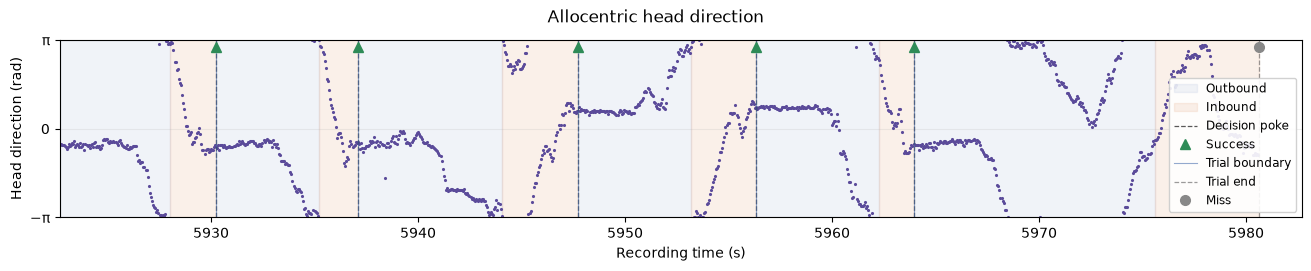

In [11]:
##### Return the Allocentric Head-Direction Figure #####

allocentric_figure, allocentric_axes, allocentric_angles = plot_allocentric_head_direction(
    angle_positions=angle_positions,
    selected_trials=selected_trials,
    individual="individual_0",
    reference_vector=(0.0, -1.0),  # Zero heading points right in the video.
    row_duration_s=60.0,
)
plt.close(allocentric_figure)
allocentric_figure

In [12]:
##### Egocentric Head Direction: Static ROI #####

def plot_egocentric_static_head_direction(
    angle_positions, 
    selected_trials, 
    individual, 
    fixed_roi_px, *,
    roi_label="North / top of video", 
    left_ear="lear", 
    right_ear="rear",
    camera_view="top_down", 
    row_duration_s=25.0,
):
    """Plot the signed bearing from the animal's head towards a fixed ROI.

    The head centre is the midpoint of the two ears. movement measures the
    angle from the head-forward vector to the vector pointing from that
    midpoint towards fixed_roi_px. Zero means facing the ROI; +pi/2 means
    the ROI is to the animal's right; -pi/2 means it is to its left. pi means
    the ROI is directly behind the head, for the top-down video convention.

    Parameters
    ----------
    angle_positions : xarray.Dataset
        Pose data already sliced to the required trials from one recording.
        position contains x/y pixel coordinates and the keypoint and
        individual dimensions. time contains increasing recording times in seconds.
        Coordinates are used as supplied, including any earlier filtering.
    selected_trials : pandas.DataFrame
        Matching trial rows used for phase shading and event annotations.
        Keep the trial columns produced by the existing DataStructure.
    individual : str
        Exact individual name in angle_positions, such as "individual_0".
    fixed_roi_px : array-like
        Fixed target (x, y) in the same video pixels as position. Use the
        same coordinates passed to plot_spatial_occupancy. The top-centre
        pixel is ((video_width - 1) / 2, 0); a measured nosepoke location can
        be supplied as its (x, y) coordinates instead.
    roi_label : str
        Name of the target displayed in the figure title. Its location is
        determined by fixed_roi_px, independently of this label.
    left_ear, right_ear : str
        Keypoint names for the animal's anatomical left and right ears.
    camera_view : str
        "top_down" or "bottom_up", passed to movement to orient the head.
    row_duration_s : float
        Positive number of recording seconds shown on each row. The final
        row keeps the same width as the preceding rows.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Static-ROI bearing figure, ready to display or save.
    axes : numpy.ndarray
        One-dimensional array of axes, ordered from earliest to latest row.
    head_angles : xarray.DataArray
        One signed bearing per supplied time sample, in radians in (-pi, pi].
        Missing/coincident ears or a target at the ear midpoint give NaN
        through movement because those cases do not define a direction.
    """
    # --- Calculate the head-forward vector with movement ---
    position = angle_positions["position"].sel(individual=individual, 
                                               drop=True
                                               )
    
    head_forward = movement.kinematics.compute_head_direction_vector(
                    data=position, 
                    left_keypoint=left_ear, 
                    right_keypoint=right_ear,
                    camera_view=camera_view,
    )


    # --- Locate the head centre and the fixed target in the same pixel space ---
    head_centre = (
        position.sel(keypoint=left_ear, drop=True)
        + position.sel(keypoint=right_ear, drop=True)
    ) / 2  # The midpoint of the two ears.

    
    fixed_roi = xr.DataArray(
        np.asarray(fixed_roi_px), dims="space", coords={"space": ["x", "y"]},
    )
    head_angles = movement.utils.vector.compute_signed_angle_2d(
        u=head_forward, v=fixed_roi - head_centre,
    )  # The second vector points from the head towards the ROI.

    # --- Divide the recording clock into equal-duration rows ---
    start = float(head_angles["time"][0])
    end = float(head_angles["time"][-1])
    row_count = max(1, int(np.ceil((end - start) / row_duration_s)))
    fig, grid = plt.subplots(
        row_count, 1, figsize=(13, 2.6 * row_count),
        squeeze=False, sharey=True, layout="constrained",
    )
    axes = grid[:, 0]

    # --- Draw the bearings and the matching trial annotations ---
    for row, ax in enumerate(axes):
        row_start = start + row * row_duration_s
        row_end = row_start + row_duration_s
        # Points keep excluded intervals and angle-wrap jumps visually separate.
        ax.plot(head_angles["time"], head_angles, ".", ms=2.5, color="#5b4b9a")
        ax.set(
            xlim=(row_start, row_end), ylim=(-np.pi, np.pi),
            xlabel="Recording time (s)", ylabel="Bearing to ROI (rad)",
        )
        ax.set_yticks([-np.pi, 0, np.pi], ["−π", "0", "π"])
        ax.grid(axis="y", alpha=0.2)
        annotate_qc_timeseries(
            ax, selected_trials, window=(row_start, row_end),
        )

    fig.suptitle(f"Egocentric head direction: {roi_label}")
    return fig, axes, head_angles


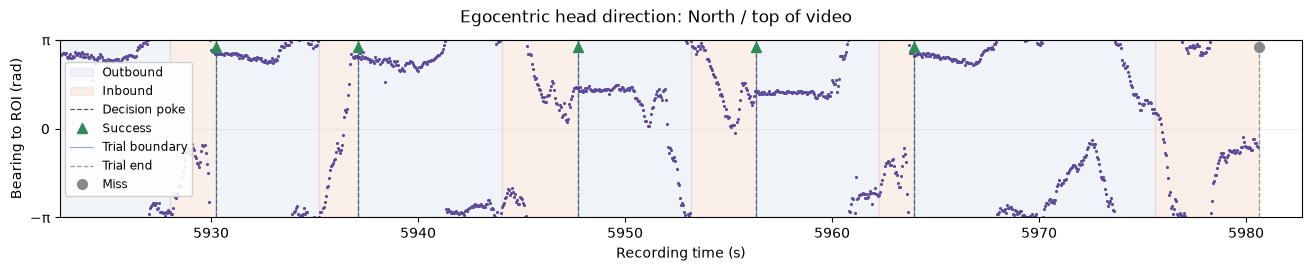

In [13]:
##### Return the Static Egocentric Head-Direction Figure #####

static_figure, static_axes, static_angles = plot_egocentric_static_head_direction(
    angle_positions=angle_positions,
    selected_trials=selected_trials,
    individual="individual_0",
    fixed_roi_px=fixed_roi_px,  # The same target shown on the occupancy figure.
    roi_label="North / top of video",
    row_duration_s=60.0,
)
plt.close(static_figure)
static_figure


## Create the figures

These calls reuse `selected_trials`, `occupancy_points` and `angle_positions` from the selection cell.
The data must describe one recording. `individual="individual_0"` below is the animal name shown in the loaded pose dataset; change that argument to choose a different named individual.

The static target is the **top-centre pixel of the matching video**. Occupancy and the static head-angle figure use the same `fixed_roi_px`. The angle figures use 25 seconds per row and radians on the vertical axis.


In [14]:
##### Video Background and Static ROI #####

# Read the video for the single recording represented by the selected trials.
session_id = selected_trials["session"].unique().item()
background_frame, video_path = read_session_video_frame(fig_ds.sessions[session_id].path)

# North/top is the centre pixel of the top edge of that video.
# fixed_roi_px = ((background_frame.shape[1] - 1) / 2, 0.0)

fixed_roi_px

array([991.75, 109.75])

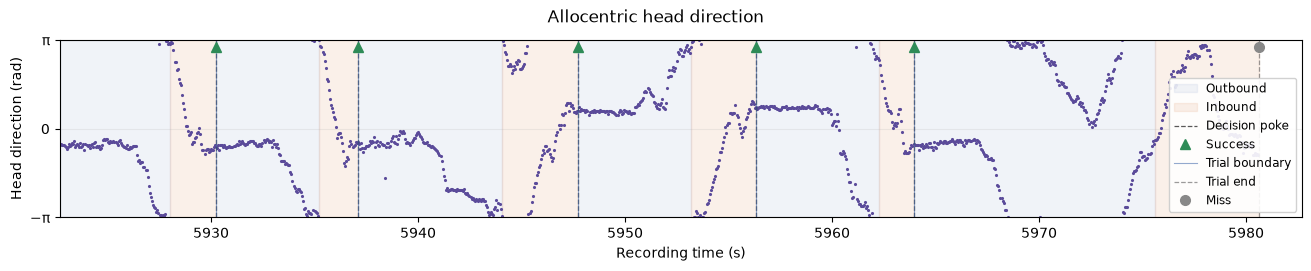

In [15]:
##### Return the Allocentric Head-Direction Figure #####

allocentric_figure, allocentric_axes, allocentric_angles = plot_allocentric_head_direction(
    angle_positions=angle_positions,
    selected_trials=selected_trials,
    individual="individual_0",
    reference_vector=(0.0, -1.0),  # Zero heading points right in the video.
    row_duration_s=60.0,
)
plt.close(allocentric_figure)
allocentric_figure


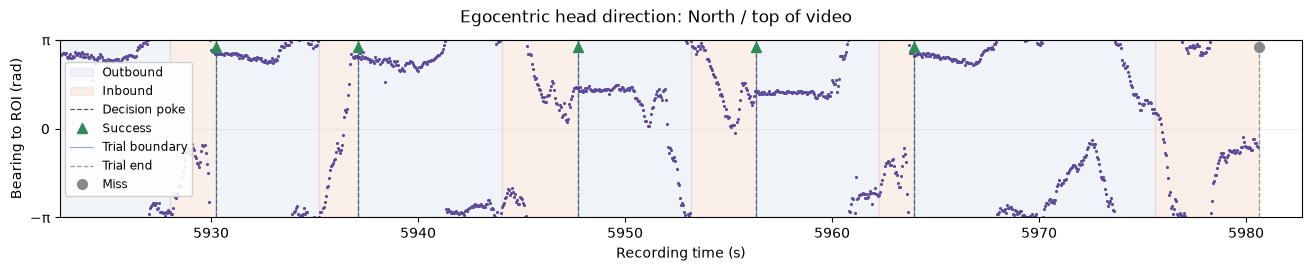

In [16]:
##### Return the Static Egocentric Head-Direction Figure #####

static_figure, static_axes, static_angles = plot_egocentric_static_head_direction(
    angle_positions=angle_positions,
    selected_trials=selected_trials,
    individual="individual_0",
    fixed_roi_px=fixed_roi_px,  # The same target shown on the occupancy figure.
    roi_label="North / top of video",
    row_duration_s=60.0,
)
plt.close(static_figure)
static_figure
